PSG_F3:A2, PSG_C3:A2 + PSG_EOG1:A2, PSG_EOG2:A2

Device : cuda
Seeds  : [42, 123, 256, 789, 999]
Output : D:\22\AA\evaluation\Context_CNN+transformer

Loading 96 subjects into RAM... Done ✅
Split loaded ✅ → Train:76  Test:20
TEST_SUBS: ['sub-121', 'sub-081', 'sub-038', 'sub-035', 'sub-104', 'sub-112', 'sub-007', 'sub-068', 'sub-093', 'sub-014', 'sub-087', 'sub-105', 'sub-017', 'sub-023', 'sub-036', 'sub-040', 'sub-045', 'sub-005', 'sub-019', 'sub-100']

Loading datasets (once for all seeds)...
  71,347 samples | 2.6 GB RAM
  19,763 samples | 0.7 GB RAM
Datasets ready.

Class weights:
  Wake: 1.973
  N1: 3.102
  N2: 0.438
  N3: 1.018
  REM: 1.107

SEED 42  (1/5)
  Ep[01/30] Loss:0.985 TrAcc:0.612 ValAcc:0.706 F1:0.676 κ:0.615 LR:3.33e-04 ← BEST
  Ep[02/30] Loss:0.613 TrAcc:0.783 ValAcc:0.650 F1:0.657 κ:0.550 LR:5.00e-04
  Ep[03/30] Loss:0.553 TrAcc:0.795 ValAcc:0.766 F1:0.714 κ:0.680 LR:4.97e-04 ← BEST
  Ep[04/30] Loss:0.515 TrAcc:0.804 ValAcc:0.767 F1:0.740 κ:0.686 LR:4.91e-04 ← BEST
  Ep[05/30] Loss:0.492 TrAcc:0.808 ValAcc:0.767 F1

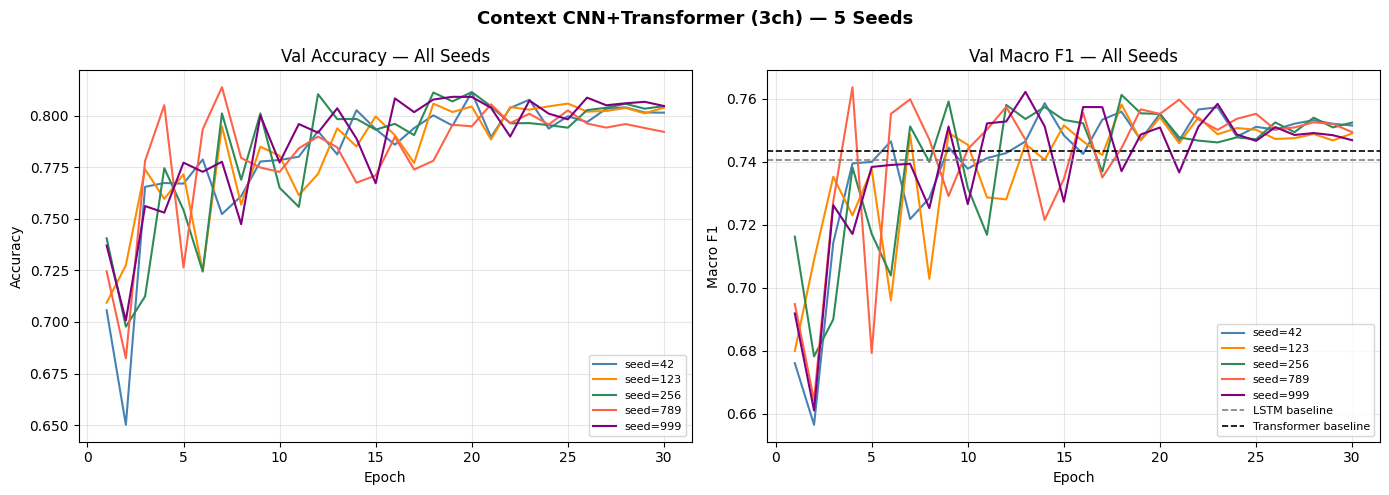

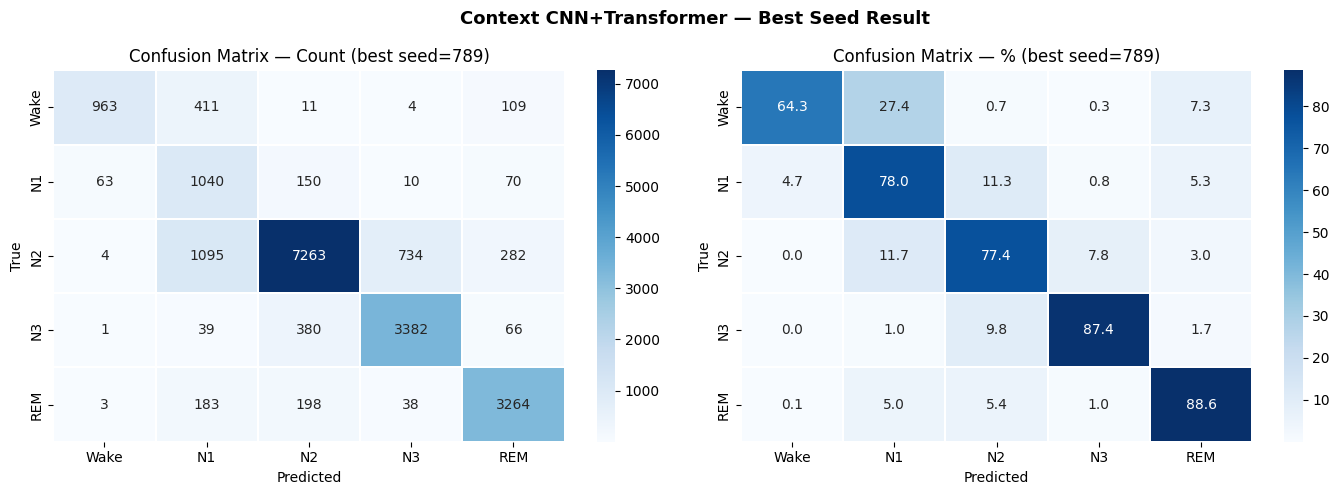

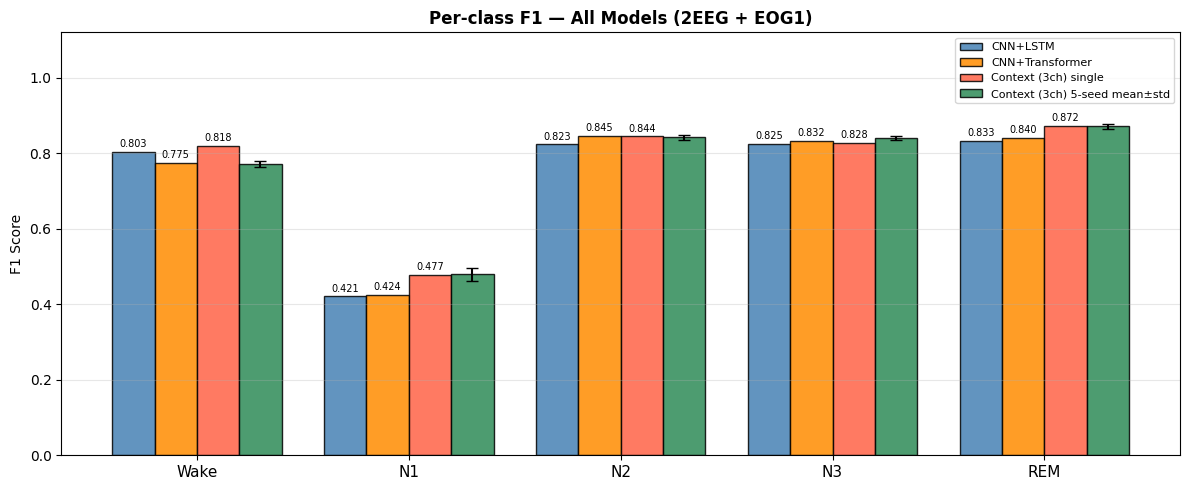

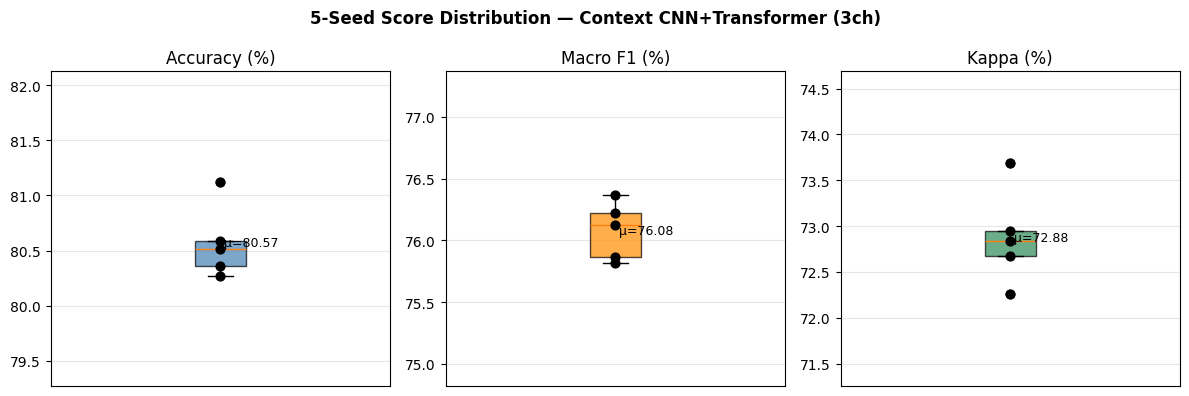


All outputs saved to: D:\22\AA\evaluation\Context_CNN+transformer

Files:
  best_seed<N>.pt              ← 5 model checkpoints
  all_seeds_log.csv            ← epoch-wise training log
  summary.csv                  ← final mean±std table
  training_curves_5seeds.png
  confusion_matrix_best_seed.png
  per_class_f1_5seed.png
  boxplot_5seeds.png
Done ✅


In [1]:
# ============================================================
# Context CNN+Transformer — PSG_F3:A2, PSG_C3:A2 + PSG_EOG1:A2, PSG_EOG2:A2
# 5-Seed Experiment — Mean ± Std Report
# ============================================================

import os
import csv
import numpy as np
import random
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------
# Paths
# -------------------------------------------------------
SAVE_PATH = r"D:\22\AA\preprocess\preprocessed_FFinal"
# SAVE_DIR   = r"D:\22\AA\evaluation\CNN"
# SAVE_PATH  = r"D:\22\thesis 3233\preprocessed_sleep_data"
EVAL_PATH  = r"D:\22\AA\evaluation\Context_CNN+transformer"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 3
WINDOW      = 2 * CONTEXT + 1
N_EPOCHS    = 30
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Seeds  : {SEEDS}")
print(f"Output : {EVAL_PATH}")

# -------------------------------------------------------
# FIXED SUBJECT SPLIT
# -------------------------------------------------------

# ============================================================
# PRELOAD
# ============================================================
all_subjects = sorted([
    f.replace(".npz","") for f in os.listdir(SAVE_PATH)
    if f.endswith(".npz") and not f.startswith("_")
])
print(f"\nLoading {len(all_subjects)} subjects into RAM...", end=" ")
npz_cache = {}
for sub in all_subjects:
    d = np.load(os.path.join(SAVE_PATH, f"{sub}.npz"))
    npz_cache[sub] = {k: d[k] for k in ["eeg","eog","labels"]}
print("Done ✅")

# ============================================================
# FIXED SPLIT — same as CNN+Transformer
# ============================================================
_train_path = os.path.join(SAVE_PATH, "_train_subs.npy")
_test_path  = os.path.join(SAVE_PATH, "_test_subs.npy")

if os.path.exists(_train_path) and os.path.exists(_test_path):
    TRAIN_SUBS = np.load(_train_path, allow_pickle=True).tolist()
    TEST_SUBS  = np.load(_test_path,  allow_pickle=True).tolist()
    print(f"Split loaded ✅ → Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")
else:
    _subs = all_subjects.copy()
    random.seed(42)
    random.shuffle(_subs)
    n          = int(0.8 * len(_subs))
    TRAIN_SUBS = _subs[:n]
    TEST_SUBS  = _subs[n:]
    np.save(_train_path, np.array(TRAIN_SUBS))
    np.save(_test_path,  np.array(TEST_SUBS))
    print(f"Split created ✅ → Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")

print(f"TEST_SUBS: {TEST_SUBS}")

# -------------------------------------------------------
# Dataset — Full RAM Loading
# -------------------------------------------------------
class ContextSleepDataset(Dataset):
    def __init__(self, subject_list, data_path, context=CONTEXT):
        self.context = context
        self.data    = []
        self.index   = []
        label_counter = Counter()

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                eeg    = d['eeg'][:, [0, 1], :]
                eog    = d['eog'][:, [0],   :]
                signal = np.concatenate(
                    [eeg, eog], axis=1
                ).astype(np.float32)
                labels = d['labels'].copy()

            sub_idx = len(self.data)
            self.data.append((signal, labels))
            n = len(labels)
            for i in range(n):
                self.index.append((sub_idx, i, n))
                label_counter[int(labels[i])] += 1

        total = len(self.index)
        ram   = sum(s.nbytes for s, _ in self.data) / 1e9
        print(f"  {total:,} samples | {ram:.1f} GB RAM")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n = self.index[idx]
        signal, labels = self.data[sub_idx]
        window_epochs  = []
        for offset in range(-self.context, self.context + 1):
            epoch_i = max(0, min(n - 1, center_i + offset))
            window_epochs.append(signal[epoch_i])
        x = np.stack(window_epochs, axis=0)
        y = int(labels[center_i])
        return torch.FloatTensor(x), torch.tensor(y, dtype=torch.long)

# Dataset একবার load করো — সব seed এ same data
print("\nLoading datasets (once for all seeds)...")
train_ds = ContextSleepDataset(TRAIN_SUBS, SAVE_PATH)
test_ds  = ContextSleepDataset(TEST_SUBS, SAVE_PATH)
print("Datasets ready.")

# -------------------------------------------------------
# Positional Encoding
# -------------------------------------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# -------------------------------------------------------
# Model
# -------------------------------------------------------
class ContextCNNTransformer(nn.Module):
    def __init__(
        self,
        in_ch=3, d_model=128, nhead=8,
        num_layers=3, dim_ff=256,
        dropout=0.4, n_classes=5, context=CONTEXT
    ):
        super().__init__()
        self.context = context
        self.d_model = d_model

        self.epoch_cnn = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=50, stride=6, padding=25),
            nn.BatchNorm1d(32), nn.GELU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(32, 64, kernel_size=8, padding=4),
            nn.BatchNorm1d(64), nn.GELU(),
            nn.Conv1d(64, d_model, kernel_size=8, padding=4),
            nn.BatchNorm1d(d_model), nn.GELU(),
            nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )

        with torch.no_grad():
            intra_seq = self.epoch_cnn(
                torch.zeros(1, in_ch, 3000)
            ).shape[2]

        self.intra_pos = PositionalEncoding(
            d_model, max_len=intra_seq + 10, dropout=dropout
        )
        self.intra_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=1
        )

        self.inter_pos = PositionalEncoding(
            d_model, max_len=WINDOW + 2, dropout=dropout
        )
        self.inter_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=num_layers
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        B, W, C, T = x.shape
        x_2d  = x.view(B * W, C, T)
        feat   = self.epoch_cnn(x_2d).permute(0, 2, 1)
        feat   = self.intra_pos(feat)
        feat   = self.intra_transformer(feat).mean(dim=1)
        feat   = feat.view(B, W, self.d_model)
        feat   = self.inter_pos(feat)
        feat   = self.inter_transformer(feat)
        center = feat[:, self.context, :]
        return self.classifier(center)

# -------------------------------------------------------
# Class Weights
# -------------------------------------------------------
label_counts = np.array(
    [9238, 5874, 41630, 17906, 16462],
    dtype=np.float32
)
class_weights   = label_counts.sum() / (5 * label_counts)
class_weights_t = torch.FloatTensor(class_weights).to(device)
print(f"\nClass weights:")
for n, w in zip(LABEL_NAMES, class_weights):
    print(f"  {n}: {w:.3f}")

# -------------------------------------------------------
# Train + Eval
# -------------------------------------------------------
def train_epoch(model, loader, optimizer, criterion, scheduler):
    model.train()
    total_loss = 0
    preds, labs = [], []
    for i, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds.extend(out.argmax(1).cpu().numpy())
        labs.extend(y.cpu().numpy())
        if (i + 1) % 300 == 0:
            print(f"  batch {i+1}/{len(loader)}", end="\r")
    acc = accuracy_score(labs, preds)
    f1  = f1_score(labs, preds, average='macro', zero_division=0)
    return total_loss / len(loader), acc, f1


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    preds, labs = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out  = model(x)
            total_loss += criterion(out, y).item()
            preds.extend(out.argmax(1).cpu().numpy())
            labs.extend(y.cpu().numpy())
    acc     = accuracy_score(labs, preds)
    f1      = f1_score(labs, preds, average='macro', zero_division=0)
    kappa   = cohen_kappa_score(labs, preds)
    per_cls = f1_score(labs, preds, average=None, zero_division=0)
    return total_loss/len(loader), acc, f1, kappa, per_cls, preds, labs

# -------------------------------------------------------
# CSV Log setup
# -------------------------------------------------------
csv_path = os.path.join(EVAL_PATH, "all_seeds_log.csv")
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'seed', 'epoch',
        'tr_loss', 'tr_acc', 'tr_f1',
        'vl_loss', 'vl_acc', 'vl_f1', 'vl_kap'
    ])

# -------------------------------------------------------
# 5-Seed Training Loop
# -------------------------------------------------------
all_seed_results = []

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}")
    print(f"SEED {seed}  ({seed_idx+1}/{len(SEEDS)})")
    print(f"{'='*60}")

    # Reproducibility
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

    # DataLoader — shuffle seed বদলায়
    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=0,
        generator=torch.Generator().manual_seed(seed)
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=0
    )

    # Model
    model     = ContextCNNTransformer(in_ch=3).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = optim.AdamW(
        model.parameters(),
        lr=5e-4, weight_decay=3e-4,
        betas=(0.9, 0.98), eps=1e-9
    )

    total_steps  = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def warmup_cosine(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(
            total_steps - warmup_steps, 1
        )
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler  = optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=warmup_cosine
    )

    best_f1    = 0.0
    best_path  = os.path.join(
        EVAL_PATH, f"best_seed{seed}.pt"
    )
    history    = []

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_acc, tr_f1 = train_epoch(
            model, train_loader,
            optimizer, criterion, scheduler
        )
        vl_loss, vl_acc, vl_f1, vl_kap, per_cls, _, _ = evaluate(
            model, test_loader, criterion
        )

        saved = ""
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), best_path)
            saved = " ← BEST"

        lr = optimizer.param_groups[0]['lr']
        history.append({
            'epoch'  : epoch,
            'tr_loss': tr_loss, 'tr_acc': tr_acc, 'tr_f1': tr_f1,
            'vl_loss': vl_loss, 'vl_acc': vl_acc, 'vl_f1': vl_f1,
            'vl_kap' : vl_kap
        })

        print(
            f"  Ep[{epoch:02d}/{N_EPOCHS}] "
            f"Loss:{tr_loss:.3f} TrAcc:{tr_acc:.3f} "
            f"ValAcc:{vl_acc:.3f} F1:{vl_f1:.3f} "
            f"κ:{vl_kap:.3f} LR:{lr:.2e}{saved}"
        )

        if epoch % 10 == 0:
            print("    Per-class F1: " + " | ".join(
                f"{LABEL_NAMES[i]}={per_cls[i]:.3f}"
                for i in range(5)
            ))

        # CSV log
        with open(csv_path, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                seed, epoch,
                f"{tr_loss:.4f}", f"{tr_acc:.4f}", f"{tr_f1:.4f}",
                f"{vl_loss:.4f}", f"{vl_acc:.4f}",
                f"{vl_f1:.4f}", f"{vl_kap:.4f}"
            ])

    # Final eval with best checkpoint
    model.load_state_dict(torch.load(best_path))
    _, fin_acc, fin_f1, fin_kap, fin_per, fin_preds, fin_labels = evaluate(
        model, test_loader, criterion
    )

    print(f"\n  Seed {seed} FINAL → "
          f"Acc={fin_acc*100:.2f}% "
          f"F1={fin_f1:.4f} "
          f"κ={fin_kap:.4f} "
          f"N1={fin_per[1]:.4f}")

    all_seed_results.append({
        'seed'   : seed,
        'acc'    : fin_acc * 100,
        'f1'     : fin_f1,
        'kappa'  : fin_kap,
        'per_cls': fin_per,
        'preds'  : fin_preds,
        'labels' : fin_labels,
        'history': history,
    })

# -------------------------------------------------------
# FINAL REPORT — Mean ± Std
# -------------------------------------------------------
print(f"\n{'='*60}")
print("5-SEED FINAL REPORT")
print(f"{'='*60}")

accs   = np.array([r['acc']   for r in all_seed_results])
f1s    = np.array([r['f1']    for r in all_seed_results])
kappas = np.array([r['kappa'] for r in all_seed_results])
n1s    = np.array([r['per_cls'][1] for r in all_seed_results])

print(f"\n{'Seed':<8} {'Acc%':>7} {'F1':>7} {'Kappa':>7} {'N1':>7}")
print("-" * 40)
for r in all_seed_results:
    print(f"{r['seed']:<8} "
          f"{r['acc']:>7.2f} "
          f"{r['f1']:>7.4f} "
          f"{r['kappa']:>7.4f} "
          f"{r['per_cls'][1]:>7.4f}")

print("-" * 40)
print(f"{'Mean':<8} "
      f"{accs.mean():>7.2f} "
      f"{f1s.mean():>7.4f} "
      f"{kappas.mean():>7.4f} "
      f"{n1s.mean():>7.4f}")
print(f"{'Std':<8} "
      f"{accs.std():>7.2f} "
      f"{f1s.std():>7.4f} "
      f"{kappas.std():>7.4f} "
      f"{n1s.std():>7.4f}")

print(f"\nPaper format:")
print(f"  Accuracy : {accs.mean():.2f} ± {accs.std():.2f}%")
print(f"  Macro F1 : {f1s.mean():.4f} ± {f1s.std():.4f}")
print(f"  Kappa    : {kappas.mean():.4f} ± {kappas.std():.4f}")
print(f"  N1 F1    : {n1s.mean():.4f} ± {n1s.std():.4f}")

# Per-class mean ± std
print(f"\nPer-class F1 (mean ± std):")
for i, name in enumerate(LABEL_NAMES):
    vals = np.array([r['per_cls'][i] for r in all_seed_results])
    print(f"  {name:6s}: {vals.mean():.4f} ± {vals.std():.4f}")

# CSV summary save
summary_path = os.path.join(EVAL_PATH, "summary.csv")
with open(summary_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['seed', 'acc', 'f1', 'kappa', 'n1',
                     'wake', 'n1_f1', 'n2', 'n3', 'rem'])
    for r in all_seed_results:
        writer.writerow([
            r['seed'],
            f"{r['acc']:.4f}",
            f"{r['f1']:.4f}",
            f"{r['kappa']:.4f}",
            f"{r['per_cls'][1]:.4f}",
            *[f"{r['per_cls'][i]:.4f}" for i in range(5)]
        ])
    writer.writerow([])
    writer.writerow(['mean', f"{accs.mean():.4f}",
                     f"{f1s.mean():.4f}", f"{kappas.mean():.4f}",
                     f"{n1s.mean():.4f}"])
    writer.writerow(['std',  f"{accs.std():.4f}",
                     f"{f1s.std():.4f}", f"{kappas.std():.4f}",
                     f"{n1s.std():.4f}"])
print(f"\nSummary CSV saved: {summary_path}")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1. Training curves — সব seed একসাথে
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue','darkorange','seagreen','tomato','purple']

for r, c in zip(all_seed_results, colors):
    eps    = [h['epoch']  for h in r['history']]
    vl_f1s = [h['vl_f1']  for h in r['history']]
    vl_acc = [h['vl_acc'] for h in r['history']]
    axes[0].plot(eps, vl_acc, color=c, lw=1.5,
                 label=f"seed={r['seed']}")
    axes[1].plot(eps, vl_f1s, color=c, lw=1.5,
                 label=f"seed={r['seed']}")

axes[0].set_title("Val Accuracy — All Seeds")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].axhline(0.7407, color='gray',  ls='--',
                lw=1.2, label='LSTM baseline')
axes[1].axhline(0.7433, color='black', ls='--',
                lw=1.2, label='Transformer baseline')
axes[1].set_title("Val Macro F1 — All Seeds")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro F1")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

fig.suptitle("Context CNN+Transformer (3ch) — 5 Seeds",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "training_curves_5seeds.png"),
            dpi=150)
plt.show()

# 2. Mean Confusion Matrix (best seed দিয়ে)
best_seed_result = max(all_seed_results, key=lambda r: r['f1'])
cm     = confusion_matrix(
    best_seed_result['labels'], best_seed_result['preds']
)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            cmap='Blues', ax=axes[0], linewidths=0.3)
axes[0].set_title(f"Confusion Matrix — Count (best seed={best_seed_result['seed']})")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

sns.heatmap(cm_pct, annot=True, fmt='.1f',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            cmap='Blues', ax=axes[1], linewidths=0.3)
axes[1].set_title(f"Confusion Matrix — % (best seed={best_seed_result['seed']})")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

fig.suptitle("Context CNN+Transformer — Best Seed Result",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_best_seed.png"),
            dpi=150)
plt.show()

# 3. Per-class F1 — mean ± std bar chart
per_cls_means = np.array([
    [r['per_cls'][i] for r in all_seed_results]
    for i in range(5)
]).mean(axis=1)
per_cls_stds = np.array([
    [r['per_cls'][i] for r in all_seed_results]
    for i in range(5)
]).std(axis=1)

# Baseline per-class
lstm_per   = [0.8026, 0.4206, 0.8232, 0.8245, 0.8328]
trf_per    = [0.7749, 0.4244, 0.8451, 0.8322, 0.8398]
ctx3ch_per = [0.8184, 0.4771, 0.8442, 0.8277, 0.8716]

x     = np.arange(5)
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 1.5*width, lstm_per,      width,
       label='CNN+LSTM',             color='steelblue',  alpha=0.85, edgecolor='k')
ax.bar(x - 0.5*width, trf_per,       width,
       label='CNN+Transformer',      color='darkorange', alpha=0.85, edgecolor='k')
ax.bar(x + 0.5*width, ctx3ch_per,    width,
       label='Context (3ch) single', color='tomato',     alpha=0.85, edgecolor='k')
ax.bar(x + 1.5*width, per_cls_means, width,
       yerr=per_cls_stds, capsize=4,
       label='Context (3ch) 5-seed mean±std',
       color='seagreen', alpha=0.85, edgecolor='k')

for bars in ax.containers[:3]:
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES, fontsize=11)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.12)
ax.set_title("Per-class F1 — All Models (2EEG + EOG1)",
             fontweight='bold', fontsize=12)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "per_class_f1_5seed.png"), dpi=150)
plt.show()

# 4. Box plot — F1 distribution across seeds
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

metrics = [
    (accs,   "Accuracy (%)",  'steelblue'),
    (f1s*100,"Macro F1 (%)",  'darkorange'),
    (kappas*100,"Kappa (%)",  'seagreen'),
]
for ax, (vals, title, color) in zip(axes, metrics):
    ax.boxplot(vals, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7))
    ax.scatter([1]*len(vals), vals,
               color='black', zorder=5, s=40)
    ax.set_title(title)
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.3)
    ymin = vals.min() - 1
    ymax = vals.max() + 1
    ax.set_ylim(ymin, ymax)
    ax.text(1, vals.mean(), f" μ={vals.mean():.2f}",
            va='center', fontsize=9)

fig.suptitle("5-Seed Score Distribution — Context CNN+Transformer (3ch)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "boxplot_5seeds.png"), dpi=150)
plt.show()

# -------------------------------------------------------
# Final summary
# -------------------------------------------------------
print(f"\n{'='*60}")
print(f"All outputs saved to: {EVAL_PATH}")
print(f"\nFiles:")
print(f"  best_seed<N>.pt              ← 5 model checkpoints")
print(f"  all_seeds_log.csv            ← epoch-wise training log")
print(f"  summary.csv                  ← final mean±std table")
print(f"  training_curves_5seeds.png")
print(f"  confusion_matrix_best_seed.png")
print(f"  per_class_f1_5seed.png")
print(f"  boxplot_5seeds.png")
print(f"{'='*60}")
print(f"Done ✅")

Device : cuda
Seeds  : [42, 123, 256, 789, 999]
Output : D:\22\AA\evaluation\Context=7_CNN+transformer

Loading 96 subjects into RAM... Done ✅
Split loaded ✅ → Train:76  Test:20
TEST_SUBS: ['sub-121', 'sub-081', 'sub-038', 'sub-035', 'sub-104', 'sub-112', 'sub-007', 'sub-068', 'sub-093', 'sub-014', 'sub-087', 'sub-105', 'sub-017', 'sub-023', 'sub-036', 'sub-040', 'sub-045', 'sub-005', 'sub-019', 'sub-100']

Loading datasets (once for all seeds)...
  71,347 samples | 2.6 GB RAM
  19,763 samples | 0.7 GB RAM
Datasets ready.

Class weights:
  Wake: 1.973
  N1: 3.102
  N2: 0.438
  N3: 1.018
  REM: 1.107

SEED 42  (1/5)
  Ep[01/30] Loss:0.974 TrAcc:0.616 ValAcc:0.702 F1:0.680 κ:0.611 LR:3.33e-04 ← BEST
  Ep[02/30] Loss:0.598 TrAcc:0.788 ValAcc:0.748 F1:0.715 κ:0.657 LR:5.00e-04 ← BEST
  Ep[03/30] Loss:0.534 TrAcc:0.804 ValAcc:0.798 F1:0.747 κ:0.716 LR:4.97e-04 ← BEST
  Ep[04/30] Loss:0.497 TrAcc:0.811 ValAcc:0.813 F1:0.766 κ:0.738 LR:4.91e-04 ← BEST
  Ep[05/30] Loss:0.472 TrAcc:0.817 ValAcc

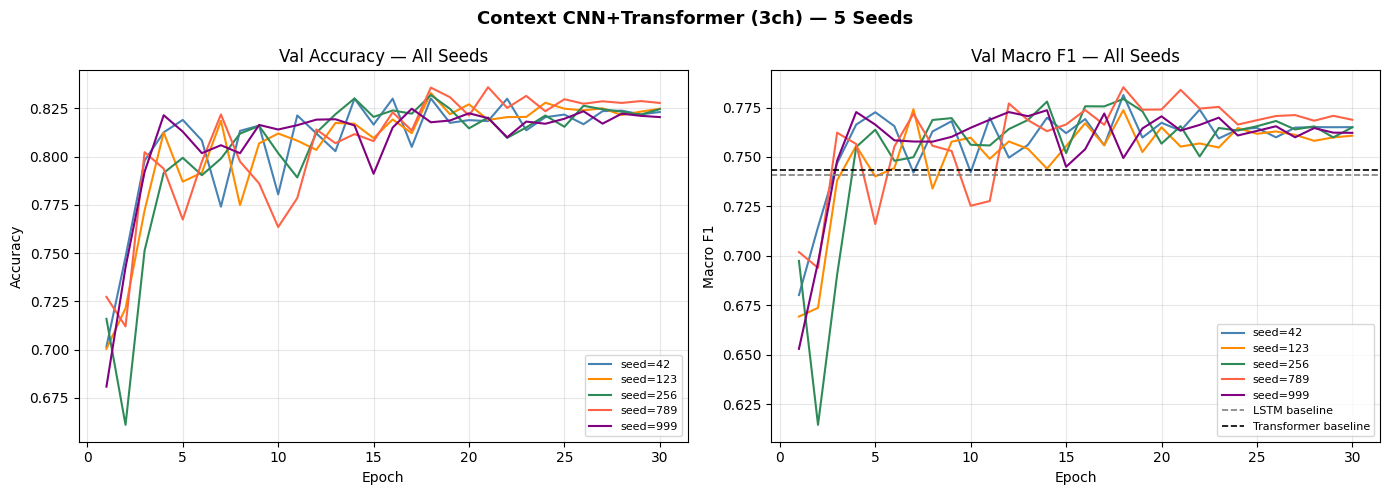

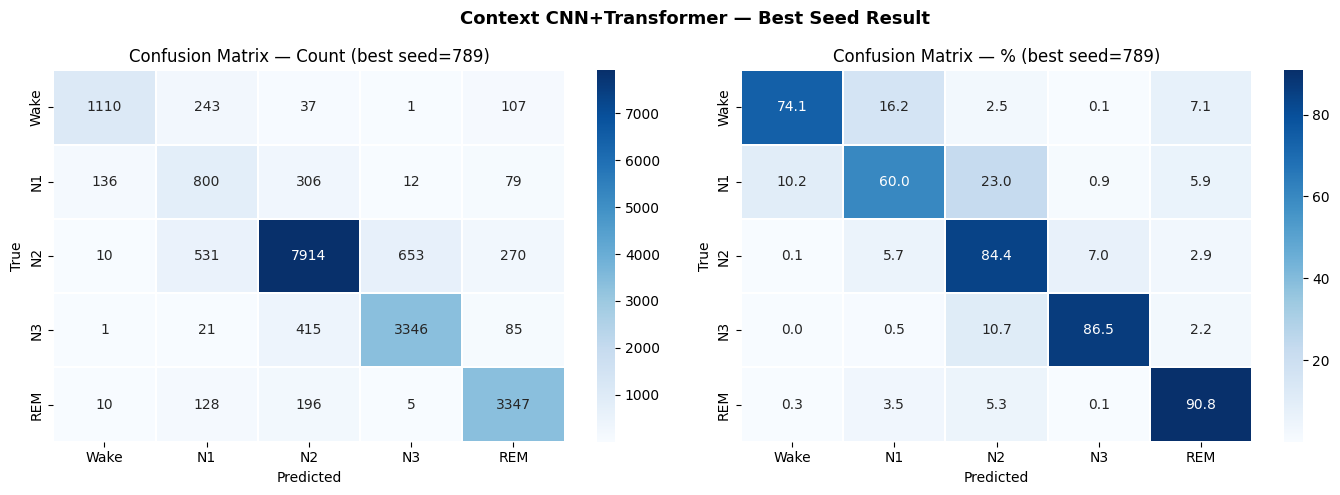

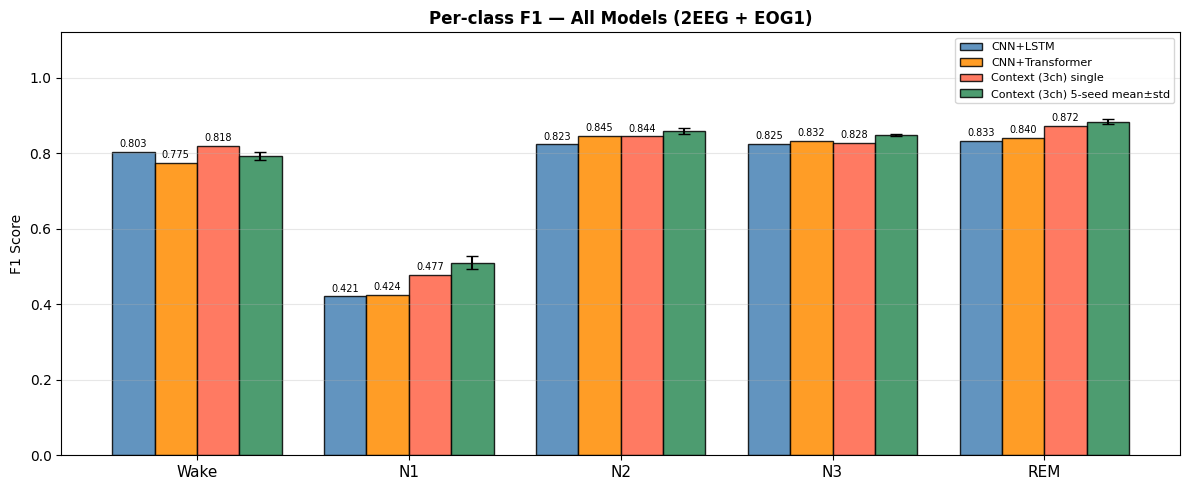

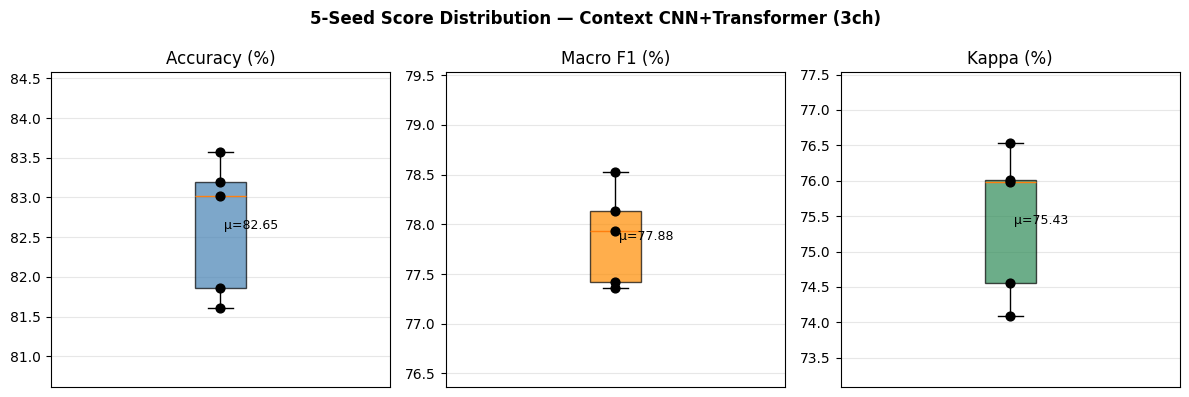


All outputs saved to: D:\22\AA\evaluation\Context=7_CNN+transformer

Files:
  best_seed<N>.pt              ← 5 model checkpoints
  all_seeds_log.csv            ← epoch-wise training log
  summary.csv                  ← final mean±std table
  training_curves_5seeds.png
  confusion_matrix_best_seed.png
  per_class_f1_5seed.png
  boxplot_5seeds.png
Done ✅


In [1]:
# ============================================================
# Context CNN+Transformer — PSG_F3:A2, PSG_C3:A2 + PSG_EOG1:A2, PSG_EOG2:A2
# 5-Seed Experiment — Mean ± Std Report
# ============================================================

import os
import csv
import numpy as np
import random
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------
# Paths
# -------------------------------------------------------
SAVE_PATH = r"D:\22\AA\preprocess\preprocessed_FFinal"
# SAVE_DIR   = r"D:\22\AA\evaluation\CNN"
# SAVE_PATH  = r"D:\22\thesis 3233\preprocessed_sleep_data"
EVAL_PATH  = r"D:\22\AA\evaluation\Context=7_CNN+transformer"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 7
WINDOW      = 2 * CONTEXT + 1
N_EPOCHS    = 30
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Seeds  : {SEEDS}")
print(f"Output : {EVAL_PATH}")

# -------------------------------------------------------
# FIXED SUBJECT SPLIT
# -------------------------------------------------------

# ============================================================
# PRELOAD
# ============================================================
all_subjects = sorted([
    f.replace(".npz","") for f in os.listdir(SAVE_PATH)
    if f.endswith(".npz") and not f.startswith("_")
])
print(f"\nLoading {len(all_subjects)} subjects into RAM...", end=" ")
npz_cache = {}
for sub in all_subjects:
    d = np.load(os.path.join(SAVE_PATH, f"{sub}.npz"))
    npz_cache[sub] = {k: d[k] for k in ["eeg","eog","labels"]}
print("Done ✅")

# ============================================================
# FIXED SPLIT — same as CNN+Transformer
# ============================================================
_train_path = os.path.join(SAVE_PATH, "_train_subs.npy")
_test_path  = os.path.join(SAVE_PATH, "_test_subs.npy")

if os.path.exists(_train_path) and os.path.exists(_test_path):
    TRAIN_SUBS = np.load(_train_path, allow_pickle=True).tolist()
    TEST_SUBS  = np.load(_test_path,  allow_pickle=True).tolist()
    print(f"Split loaded ✅ → Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")
else:
    _subs = all_subjects.copy()
    random.seed(42)
    random.shuffle(_subs)
    n          = int(0.8 * len(_subs))
    TRAIN_SUBS = _subs[:n]
    TEST_SUBS  = _subs[n:]
    np.save(_train_path, np.array(TRAIN_SUBS))
    np.save(_test_path,  np.array(TEST_SUBS))
    print(f"Split created ✅ → Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")

print(f"TEST_SUBS: {TEST_SUBS}")

# -------------------------------------------------------
# Dataset — Full RAM Loading
# -------------------------------------------------------
class ContextSleepDataset(Dataset):
    def __init__(self, subject_list, data_path, context=CONTEXT):
        self.context = context
        self.data    = []
        self.index   = []
        label_counter = Counter()

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                eeg    = d['eeg'][:, [0, 1], :]
                eog    = d['eog'][:, [0],   :]
                signal = np.concatenate(
                    [eeg, eog], axis=1
                ).astype(np.float32)
                labels = d['labels'].copy()

            sub_idx = len(self.data)
            self.data.append((signal, labels))
            n = len(labels)
            for i in range(n):
                self.index.append((sub_idx, i, n))
                label_counter[int(labels[i])] += 1

        total = len(self.index)
        ram   = sum(s.nbytes for s, _ in self.data) / 1e9
        print(f"  {total:,} samples | {ram:.1f} GB RAM")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n = self.index[idx]
        signal, labels = self.data[sub_idx]
        window_epochs  = []
        for offset in range(-self.context, self.context + 1):
            epoch_i = max(0, min(n - 1, center_i + offset))
            window_epochs.append(signal[epoch_i])
        x = np.stack(window_epochs, axis=0)
        y = int(labels[center_i])
        return torch.FloatTensor(x), torch.tensor(y, dtype=torch.long)

# Dataset একবার load করো — সব seed এ same data
print("\nLoading datasets (once for all seeds)...")
train_ds = ContextSleepDataset(TRAIN_SUBS, SAVE_PATH)
test_ds  = ContextSleepDataset(TEST_SUBS, SAVE_PATH)
print("Datasets ready.")

# -------------------------------------------------------
# Positional Encoding
# -------------------------------------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# -------------------------------------------------------
# Model
# -------------------------------------------------------
class ContextCNNTransformer(nn.Module):
    def __init__(
        self,
        in_ch=3, d_model=128, nhead=8,
        num_layers=3, dim_ff=256,
        dropout=0.4, n_classes=5, context=CONTEXT
    ):
        super().__init__()
        self.context = context
        self.d_model = d_model

        self.epoch_cnn = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=50, stride=6, padding=25),
            nn.BatchNorm1d(32), nn.GELU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(32, 64, kernel_size=8, padding=4),
            nn.BatchNorm1d(64), nn.GELU(),
            nn.Conv1d(64, d_model, kernel_size=8, padding=4),
            nn.BatchNorm1d(d_model), nn.GELU(),
            nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )

        with torch.no_grad():
            intra_seq = self.epoch_cnn(
                torch.zeros(1, in_ch, 3000)
            ).shape[2]

        self.intra_pos = PositionalEncoding(
            d_model, max_len=intra_seq + 10, dropout=dropout
        )
        self.intra_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=1
        )

        self.inter_pos = PositionalEncoding(
            d_model, max_len=WINDOW + 2, dropout=dropout
        )
        self.inter_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_ff, dropout=dropout,
                activation='gelu', batch_first=True, norm_first=True
            ), num_layers=num_layers
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        B, W, C, T = x.shape
        x_2d  = x.view(B * W, C, T)
        feat   = self.epoch_cnn(x_2d).permute(0, 2, 1)
        feat   = self.intra_pos(feat)
        feat   = self.intra_transformer(feat).mean(dim=1)
        feat   = feat.view(B, W, self.d_model)
        feat   = self.inter_pos(feat)
        feat   = self.inter_transformer(feat)
        center = feat[:, self.context, :]
        return self.classifier(center)

# -------------------------------------------------------
# Class Weights
# -------------------------------------------------------
label_counts = np.array(
    [9238, 5874, 41630, 17906, 16462],
    dtype=np.float32
)
class_weights   = label_counts.sum() / (5 * label_counts)
class_weights_t = torch.FloatTensor(class_weights).to(device)
print(f"\nClass weights:")
for n, w in zip(LABEL_NAMES, class_weights):
    print(f"  {n}: {w:.3f}")

# -------------------------------------------------------
# Train + Eval
# -------------------------------------------------------
def train_epoch(model, loader, optimizer, criterion, scheduler):
    model.train()
    total_loss = 0
    preds, labs = [], []
    for i, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds.extend(out.argmax(1).cpu().numpy())
        labs.extend(y.cpu().numpy())
        if (i + 1) % 300 == 0:
            print(f"  batch {i+1}/{len(loader)}", end="\r")
    acc = accuracy_score(labs, preds)
    f1  = f1_score(labs, preds, average='macro', zero_division=0)
    return total_loss / len(loader), acc, f1


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    preds, labs = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out  = model(x)
            total_loss += criterion(out, y).item()
            preds.extend(out.argmax(1).cpu().numpy())
            labs.extend(y.cpu().numpy())
    acc     = accuracy_score(labs, preds)
    f1      = f1_score(labs, preds, average='macro', zero_division=0)
    kappa   = cohen_kappa_score(labs, preds)
    per_cls = f1_score(labs, preds, average=None, zero_division=0)
    return total_loss/len(loader), acc, f1, kappa, per_cls, preds, labs

# -------------------------------------------------------
# CSV Log setup
# -------------------------------------------------------
csv_path = os.path.join(EVAL_PATH, "all_seeds_log.csv")
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'seed', 'epoch',
        'tr_loss', 'tr_acc', 'tr_f1',
        'vl_loss', 'vl_acc', 'vl_f1', 'vl_kap'
    ])

# -------------------------------------------------------
# 5-Seed Training Loop
# -------------------------------------------------------
all_seed_results = []

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}")
    print(f"SEED {seed}  ({seed_idx+1}/{len(SEEDS)})")
    print(f"{'='*60}")

    # Reproducibility
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

    # DataLoader — shuffle seed বদলায়
    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=0,
        generator=torch.Generator().manual_seed(seed)
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=0
    )

    # Model
    model     = ContextCNNTransformer(in_ch=3).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = optim.AdamW(
        model.parameters(),
        lr=5e-4, weight_decay=3e-4,
        betas=(0.9, 0.98), eps=1e-9
    )

    total_steps  = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def warmup_cosine(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(
            total_steps - warmup_steps, 1
        )
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler  = optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=warmup_cosine
    )

    best_f1    = 0.0
    best_path  = os.path.join(
        EVAL_PATH, f"best_seed{seed}.pt"
    )
    history    = []

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_acc, tr_f1 = train_epoch(
            model, train_loader,
            optimizer, criterion, scheduler
        )
        vl_loss, vl_acc, vl_f1, vl_kap, per_cls, _, _ = evaluate(
            model, test_loader, criterion
        )

        saved = ""
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), best_path)
            saved = " ← BEST"

        lr = optimizer.param_groups[0]['lr']
        history.append({
            'epoch'  : epoch,
            'tr_loss': tr_loss, 'tr_acc': tr_acc, 'tr_f1': tr_f1,
            'vl_loss': vl_loss, 'vl_acc': vl_acc, 'vl_f1': vl_f1,
            'vl_kap' : vl_kap
        })

        print(
            f"  Ep[{epoch:02d}/{N_EPOCHS}] "
            f"Loss:{tr_loss:.3f} TrAcc:{tr_acc:.3f} "
            f"ValAcc:{vl_acc:.3f} F1:{vl_f1:.3f} "
            f"κ:{vl_kap:.3f} LR:{lr:.2e}{saved}"
        )

        if epoch % 10 == 0:
            print("    Per-class F1: " + " | ".join(
                f"{LABEL_NAMES[i]}={per_cls[i]:.3f}"
                for i in range(5)
            ))

        # CSV log
        with open(csv_path, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                seed, epoch,
                f"{tr_loss:.4f}", f"{tr_acc:.4f}", f"{tr_f1:.4f}",
                f"{vl_loss:.4f}", f"{vl_acc:.4f}",
                f"{vl_f1:.4f}", f"{vl_kap:.4f}"
            ])

    # Final eval with best checkpoint
    model.load_state_dict(torch.load(best_path))
    _, fin_acc, fin_f1, fin_kap, fin_per, fin_preds, fin_labels = evaluate(
        model, test_loader, criterion
    )

    print(f"\n  Seed {seed} FINAL → "
          f"Acc={fin_acc*100:.2f}% "
          f"F1={fin_f1:.4f} "
          f"κ={fin_kap:.4f} "
          f"N1={fin_per[1]:.4f}")

    all_seed_results.append({
        'seed'   : seed,
        'acc'    : fin_acc * 100,
        'f1'     : fin_f1,
        'kappa'  : fin_kap,
        'per_cls': fin_per,
        'preds'  : fin_preds,
        'labels' : fin_labels,
        'history': history,
    })

# -------------------------------------------------------
# FINAL REPORT — Mean ± Std
# -------------------------------------------------------
print(f"\n{'='*60}")
print("5-SEED FINAL REPORT")
print(f"{'='*60}")

accs   = np.array([r['acc']   for r in all_seed_results])
f1s    = np.array([r['f1']    for r in all_seed_results])
kappas = np.array([r['kappa'] for r in all_seed_results])
n1s    = np.array([r['per_cls'][1] for r in all_seed_results])

print(f"\n{'Seed':<8} {'Acc%':>7} {'F1':>7} {'Kappa':>7} {'N1':>7}")
print("-" * 40)
for r in all_seed_results:
    print(f"{r['seed']:<8} "
          f"{r['acc']:>7.2f} "
          f"{r['f1']:>7.4f} "
          f"{r['kappa']:>7.4f} "
          f"{r['per_cls'][1]:>7.4f}")

print("-" * 40)
print(f"{'Mean':<8} "
      f"{accs.mean():>7.2f} "
      f"{f1s.mean():>7.4f} "
      f"{kappas.mean():>7.4f} "
      f"{n1s.mean():>7.4f}")
print(f"{'Std':<8} "
      f"{accs.std():>7.2f} "
      f"{f1s.std():>7.4f} "
      f"{kappas.std():>7.4f} "
      f"{n1s.std():>7.4f}")

print(f"\nPaper format:")
print(f"  Accuracy : {accs.mean():.2f} ± {accs.std():.2f}%")
print(f"  Macro F1 : {f1s.mean():.4f} ± {f1s.std():.4f}")
print(f"  Kappa    : {kappas.mean():.4f} ± {kappas.std():.4f}")
print(f"  N1 F1    : {n1s.mean():.4f} ± {n1s.std():.4f}")

# Per-class mean ± std
print(f"\nPer-class F1 (mean ± std):")
for i, name in enumerate(LABEL_NAMES):
    vals = np.array([r['per_cls'][i] for r in all_seed_results])
    print(f"  {name:6s}: {vals.mean():.4f} ± {vals.std():.4f}")

# CSV summary save
summary_path = os.path.join(EVAL_PATH, "summary.csv")
with open(summary_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['seed', 'acc', 'f1', 'kappa', 'n1',
                     'wake', 'n1_f1', 'n2', 'n3', 'rem'])
    for r in all_seed_results:
        writer.writerow([
            r['seed'],
            f"{r['acc']:.4f}",
            f"{r['f1']:.4f}",
            f"{r['kappa']:.4f}",
            f"{r['per_cls'][1]:.4f}",
            *[f"{r['per_cls'][i]:.4f}" for i in range(5)]
        ])
    writer.writerow([])
    writer.writerow(['mean', f"{accs.mean():.4f}",
                     f"{f1s.mean():.4f}", f"{kappas.mean():.4f}",
                     f"{n1s.mean():.4f}"])
    writer.writerow(['std',  f"{accs.std():.4f}",
                     f"{f1s.std():.4f}", f"{kappas.std():.4f}",
                     f"{n1s.std():.4f}"])
print(f"\nSummary CSV saved: {summary_path}")

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1. Training curves — সব seed একসাথে
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue','darkorange','seagreen','tomato','purple']

for r, c in zip(all_seed_results, colors):
    eps    = [h['epoch']  for h in r['history']]
    vl_f1s = [h['vl_f1']  for h in r['history']]
    vl_acc = [h['vl_acc'] for h in r['history']]
    axes[0].plot(eps, vl_acc, color=c, lw=1.5,
                 label=f"seed={r['seed']}")
    axes[1].plot(eps, vl_f1s, color=c, lw=1.5,
                 label=f"seed={r['seed']}")

axes[0].set_title("Val Accuracy — All Seeds")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].axhline(0.7407, color='gray',  ls='--',
                lw=1.2, label='LSTM baseline')
axes[1].axhline(0.7433, color='black', ls='--',
                lw=1.2, label='Transformer baseline')
axes[1].set_title("Val Macro F1 — All Seeds")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro F1")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

fig.suptitle("Context CNN+Transformer (3ch) — 5 Seeds",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "training_curves_5seeds.png"),
            dpi=150)
plt.show()

# 2. Mean Confusion Matrix (best seed দিয়ে)
best_seed_result = max(all_seed_results, key=lambda r: r['f1'])
cm     = confusion_matrix(
    best_seed_result['labels'], best_seed_result['preds']
)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            cmap='Blues', ax=axes[0], linewidths=0.3)
axes[0].set_title(f"Confusion Matrix — Count (best seed={best_seed_result['seed']})")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

sns.heatmap(cm_pct, annot=True, fmt='.1f',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            cmap='Blues', ax=axes[1], linewidths=0.3)
axes[1].set_title(f"Confusion Matrix — % (best seed={best_seed_result['seed']})")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

fig.suptitle("Context CNN+Transformer — Best Seed Result",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_best_seed.png"),
            dpi=150)
plt.show()

# 3. Per-class F1 — mean ± std bar chart
per_cls_means = np.array([
    [r['per_cls'][i] for r in all_seed_results]
    for i in range(5)
]).mean(axis=1)
per_cls_stds = np.array([
    [r['per_cls'][i] for r in all_seed_results]
    for i in range(5)
]).std(axis=1)

# Baseline per-class
lstm_per   = [0.8026, 0.4206, 0.8232, 0.8245, 0.8328]
trf_per    = [0.7749, 0.4244, 0.8451, 0.8322, 0.8398]
ctx3ch_per = [0.8184, 0.4771, 0.8442, 0.8277, 0.8716]

x     = np.arange(5)
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 1.5*width, lstm_per,      width,
       label='CNN+LSTM',             color='steelblue',  alpha=0.85, edgecolor='k')
ax.bar(x - 0.5*width, trf_per,       width,
       label='CNN+Transformer',      color='darkorange', alpha=0.85, edgecolor='k')
ax.bar(x + 0.5*width, ctx3ch_per,    width,
       label='Context (3ch) single', color='tomato',     alpha=0.85, edgecolor='k')
ax.bar(x + 1.5*width, per_cls_means, width,
       yerr=per_cls_stds, capsize=4,
       label='Context (3ch) 5-seed mean±std',
       color='seagreen', alpha=0.85, edgecolor='k')

for bars in ax.containers[:3]:
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES, fontsize=11)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.12)
ax.set_title("Per-class F1 — All Models (2EEG + EOG1)",
             fontweight='bold', fontsize=12)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "per_class_f1_5seed.png"), dpi=150)
plt.show()

# 4. Box plot — F1 distribution across seeds
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

metrics = [
    (accs,   "Accuracy (%)",  'steelblue'),
    (f1s*100,"Macro F1 (%)",  'darkorange'),
    (kappas*100,"Kappa (%)",  'seagreen'),
]
for ax, (vals, title, color) in zip(axes, metrics):
    ax.boxplot(vals, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7))
    ax.scatter([1]*len(vals), vals,
               color='black', zorder=5, s=40)
    ax.set_title(title)
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.3)
    ymin = vals.min() - 1
    ymax = vals.max() + 1
    ax.set_ylim(ymin, ymax)
    ax.text(1, vals.mean(), f" μ={vals.mean():.2f}",
            va='center', fontsize=9)

fig.suptitle("5-Seed Score Distribution — Context CNN+Transformer (3ch)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "boxplot_5seeds.png"), dpi=150)
plt.show()

# -------------------------------------------------------
# Final summary
# -------------------------------------------------------
print(f"\n{'='*60}")
print(f"All outputs saved to: {EVAL_PATH}")
print(f"\nFiles:")
print(f"  best_seed<N>.pt              ← 5 model checkpoints")
print(f"  all_seeds_log.csv            ← epoch-wise training log")
print(f"  summary.csv                  ← final mean±std table")
print(f"  training_curves_5seeds.png")
print(f"  confusion_matrix_best_seed.png")
print(f"  per_class_f1_5seed.png")
print(f"  boxplot_5seeds.png")
print(f"{'='*60}")
print(f"Done ✅")